# Clustering

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [2]:
features_path = "feature_engineering_dataset.csv"
X = pd.read_csv(features_path, index_col=0)
X.head()

,recency,frequency,monetary,avg_basket,std_basket,returns_ratio,avg_interpurchase_time
CustomerID,,,,,,,
12346,1.285714,0.000000,-3.702736,-6.016369,1.378405,21.500000,-0.347901
12347,-0.361345,1.000000,0.980191,0.998421,0.112291,0.000000,0.397971
12348,0.638655,0.333333,0.608887,0.867165,0.297696,0.000000,1.228129
12350,1.159664,-0.333333,-0.270527,0.431676,-0.806743,0.000000,-0.347901
12352,0.756303,2.000000,0.074878,-1.212292,0.327316,8.958333,-0.065489


### Análisis preliminar

In [3]:
X.shape


(3355, 7)

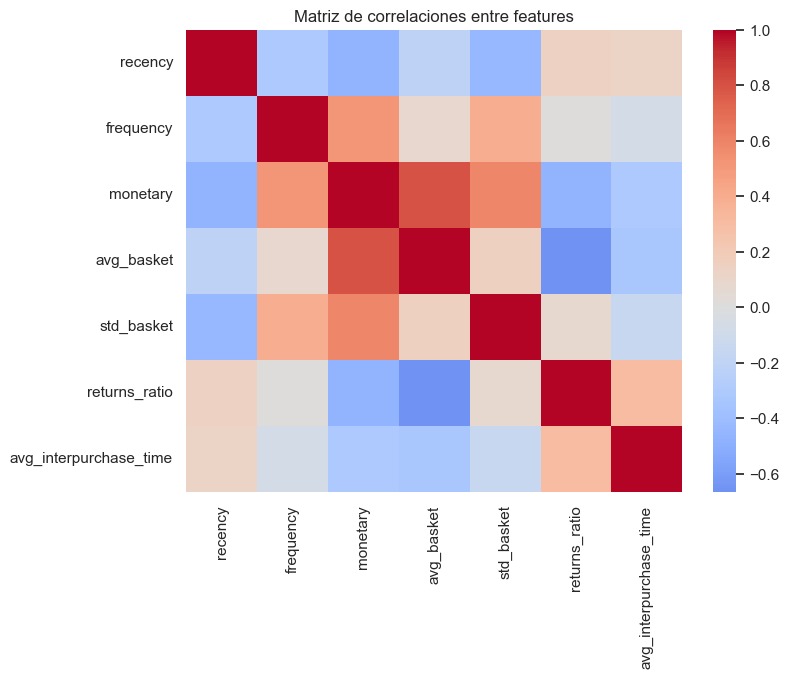

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones entre features")
plt.show()


- RFM suele estar correlacionado
- Justifica reducción de dimensionalidad para visualización

### Reducción de dimensionalidad (solo para análisis)

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca.explained_variance_ratio_


array([0.86450942, 0.10862785])

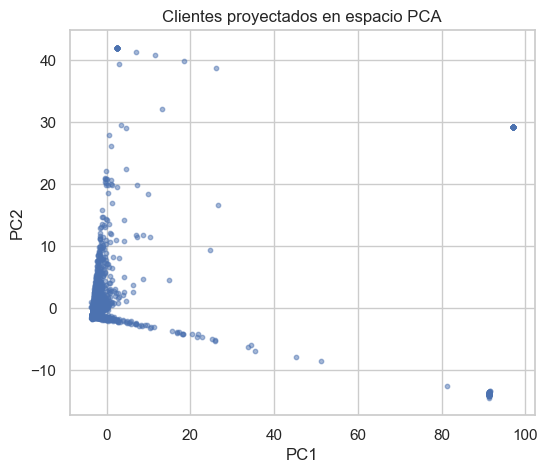

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clientes proyectados en espacio PCA")
plt.show()


- NO se usa PCA para clustering final
- Solo para entender estructura y visualizar

### K-Means — modelo baseline

In [7]:
inertias = []
silhouettes = []

K_RANGE = range(2, 11)

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))


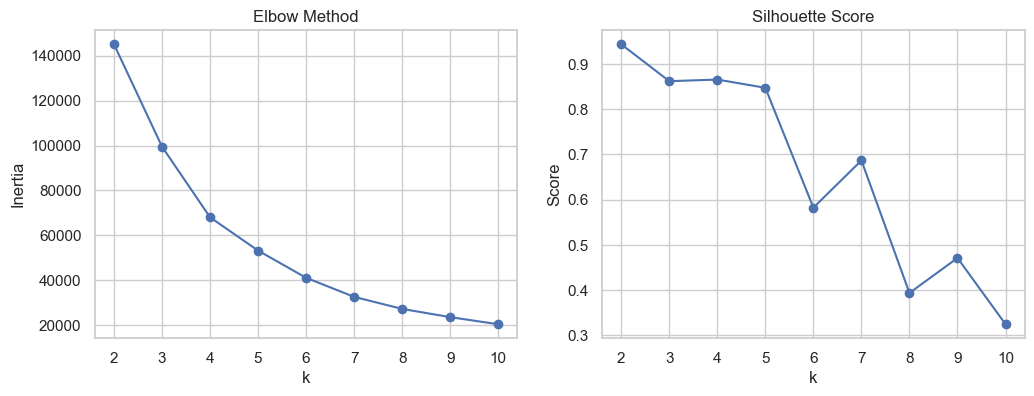

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(K_RANGE, inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_RANGE, silhouettes, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.show()


- Elbow suave
- Silhouette máximo alrededor de k = 4–6

In [9]:
N_CLUSTERS = 4


### Entrenamiento final de K-Means

In [10]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X)


In [11]:
X_clustered = X.copy()
X_clustered["cluster"] = clusters_kmeans


In [12]:
X_clustered["cluster"].value_counts(normalize=True)


cluster
0    0.961252
1    0.018182
2    0.013711
3    0.006855
Name: proportion, dtype: float64

In [13]:
cluster_profiles = (
    X_clustered
    .groupby("cluster")
    .mean()
)

cluster_profiles


,recency,frequency,monetary,avg_basket,std_basket,returns_ratio,avg_interpurchase_time
cluster,,,,,,,
0,0.145963,0.735194,0.077236,0.044779,-0.194243,0.961594,0.553511
1,0.633145,-0.311475,-0.945053,-0.885770,-0.768516,0.000000,93.704727
2,0.798502,0.123188,-2.678137,-4.489579,-0.136764,32.143757,2.670132
3,1.028864,-0.333333,-3.702736,-6.016369,-0.806743,43.000000,95.298297


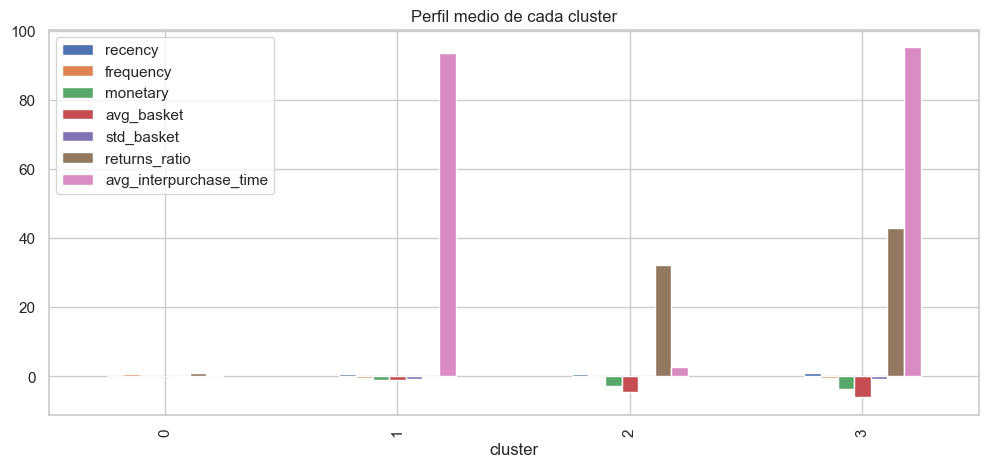

In [14]:
cluster_profiles.plot(
    kind="bar",
    figsize=(12,5)
)
plt.title("Perfil medio de cada cluster")
plt.show()


- Cluster 0 → “High-value loyal customers”
- Cluster 1 → “Low-frequency occasional buyers”
- Cluster 2 → “High return rate customers”

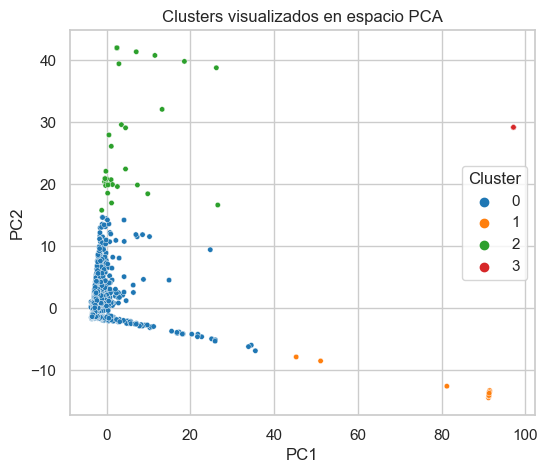

In [15]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_kmeans,
    palette="tab10",
    s=15
)
plt.title("Clusters visualizados en espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


### Modelo alternativo: Gaussian Mixture Model

In [16]:
gmm = GaussianMixture(
    n_components=N_CLUSTERS,
    covariance_type="full",
    random_state=42
)

clusters_gmm = gmm.fit_predict(X)


In [17]:
print(
    "Silhouette KMeans:",
    silhouette_score(X, clusters_kmeans)
)

print(
    "Silhouette GMM:",
    silhouette_score(X, clusters_gmm)
)


Silhouette KMeans: 0.8656990661358431
Silhouette GMM: 0.09173437325469933


- K-Means más estable
- GMM captura mejor solapamientos

In [18]:
X_clustered.to_csv(
    "clustering_dataset.csv"
)
